In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle
from scipy.stats import pearsonr

from utils.misc.results_saving import save_results, load_results, load_results_for_model_and_revisions, load_all_results
from utils.model_definitions.text_automodel_wrapper import TextModelSpecifications

from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel
from scipy.stats import pearsonr, rankdata, norm
import dcor
from minepy import MINE
from scipy.stats import kendalltau
from matplotlib.ticker import FormatStrFormatter

plt.rcParams.update({'font.size': 14})
plt.figure(dpi=300)

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
/ext3/miniconda3/envs/infoflow/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

In [2]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='results')

# Single Model, Average Metric vs Average Main Score for each layer

## old

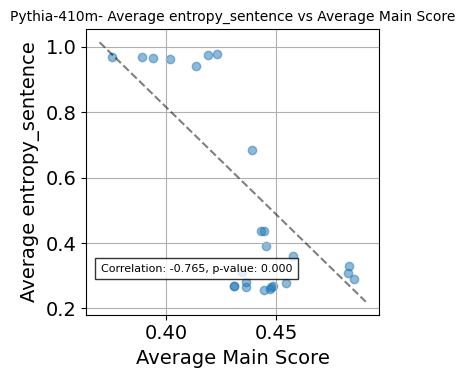

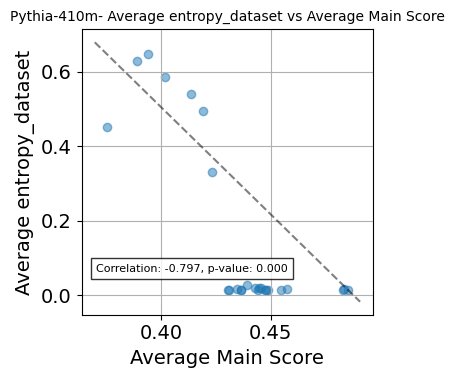

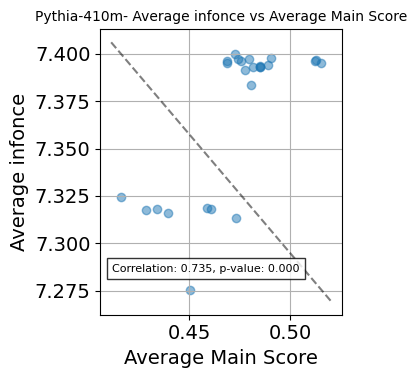

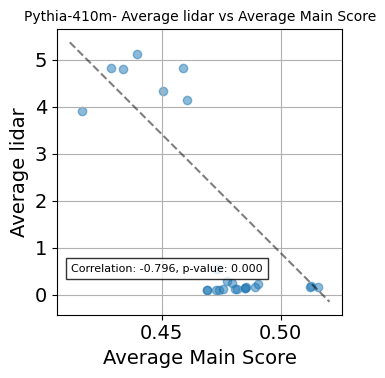

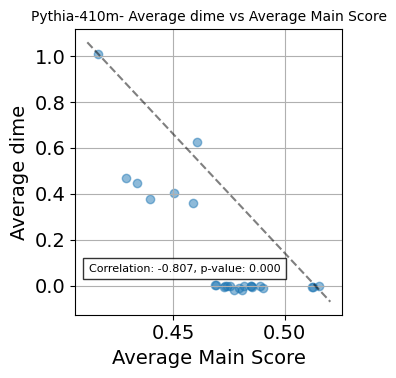

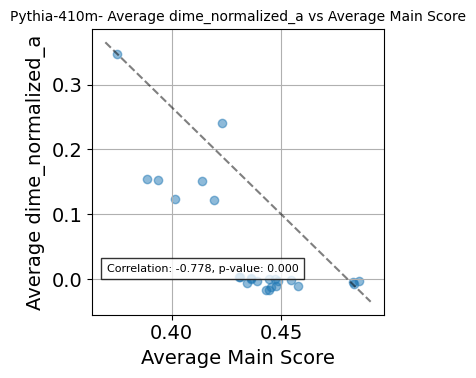

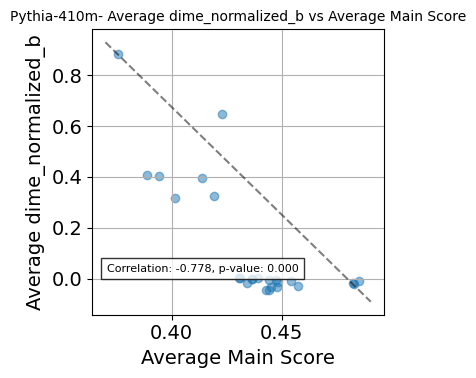

In [3]:
METRICS_CHOICES = ['entropy_sentence', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    x_values = []  # Main scores
    y_values = []  # Entropy values
    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        
        # Calculate average main score for this layer
        main_scores = []
        metric_values = []
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_sentence']['maxEntropy'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(metric_values))

    # Create square scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(x_values, y_values, alpha=0.5)
    plt.xlabel('Average Main Score')
    plt.ylabel(f'Average {METRIC_TO_PLOT}')
    plt.title(f'{model_specs.model_family}-{model_specs.model_size}- Average {METRIC_TO_PLOT} vs Average Main Score', fontsize=10)
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(x_values, y_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

## new

In [3]:
all_results.keys()

dict_keys(['roberta_CLS', 'LLM2Vec-mntp-unsup-simcse', 'Pythia', 'roberta_mean_pooling', 'LLM2Vec-mntp', 'mamba', 'bert_mean_pooling', 'bert_CLS', 'LLM2Vec-mntp-supervised'])

In [32]:
all_results["mamba"]["370m"].keys(), all_results["bert_mean_pooling"]["base"].keys()

(dict_keys(['main']), dict_keys(['main']))

In [41]:
all_results["bert_mean_pooling"]["base"]["main"]

{'layer_0': {'MTOPDomainClassification': {'main_score': 0.822298221614227,
   'dataset_name': 'mtop_domain',
   'lidar': {'maxEntropy': 0.832517423246028,
    'raw': 5.531070709228516,
    'logN': 0.6595464648858227,
    'logNlogD': 0.09927262772859384,
    'logD': 0.832517423246028},
   'dime': {'maxEntropy': 0.6232381048122727,
    'raw': 4.1406629220581905,
    'logN': 0.49374881213699034,
    'logNlogD': 0.07431734476386924,
    'logD': 0.6232381048122727},
   'infonce': {'raw': 9.07112594521092},
   'entropy_sentence': {'maxEntropy': array([0.82, 0.78, 0.81, 0.83, 0.84, 0.85, 0.84, 0.83, 0.82, 0.81, 0.8 ,
           0.79, 0.8 ]),
    'raw': array([2.46, 2.33, 2.43, 2.49, 2.5 , 2.54, 2.51, 2.5 , 2.46, 2.43, 2.41,
           2.38, 2.41]),
    'logN': array([0.82, 0.78, 0.81, 0.83, 0.84, 0.85, 0.84, 0.83, 0.82, 0.81, 0.8 ,
           0.79, 0.8 ]),
    'logNlogD': array([0.12, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13, 0.13, 0.12, 0.12, 0.12,
           0.12, 0.12]),
    'logD': array([0.37,

In [37]:
all_results["Pythia"]["410m"]["main"]["layer_0"]

{'MTOPDomainClassification': {'main_score': 0.8025763793889649,
  'dataset_name': 'mtop_domain',
  'lidar': {'maxEntropy': 0.6164810314197497,
   'raw': 4.258500099182129,
   'logN': 0.6164810314197497,
   'logNlogD': 0.08893941268313862,
   'logD': 0.6143716974715216},
  'dime': {'maxEntropy': 0.14862891072994064,
   'raw': 1.0266921427041122,
   'logN': 0.14862891072994064,
   'logNlogD': 0.021442619244281383,
   'logD': 0.14812036627988867},
  'infonce': {'raw': 7.596565341510044}},
 'EmotionClassification': {'main_score': 0.26890000000000003,
  'dataset_name': 'emotion',
  'entropy_dataset': {'maxEntropy': 0.4392716980388274,
   'raw': 3.034381391035157,
   'logN': 0.4392716980388274,
   'logNlogD': 0.06337351003634904,
   'logD': 0.4377686985012175},
  'lidar': {'maxEntropy': 0.6109773294083002,
   'raw': 4.220481872558594,
   'logN': 0.6109773294083002,
   'logNlogD': 0.08814539632329374,
   'logD': 0.6088868267702049},
  'dime': {'maxEntropy': 0.10541837328470502,
   'raw': 0.72

In [39]:
all_results["mamba"]["370m"]["main"]

{'layer_0': {'MTOPDomainClassification': {'main_score': 0.7619243046055632,
   'dataset_name': 'mtop_domain'},
  'EmotionClassification': {'main_score': 0.25355000000000005,
   'dataset_name': 'emotion'},
  'SprintDuplicateQuestions': {'main_score': 0.4341651211156417,
   'dataset_name': 'sprintduplicatequestions-pairclassification'},
  'STS13': {'main_score': 0.2895365719978077, 'dataset_name': 'sts13-sts'},
  'STS12': {'main_score': 0.346170618412656, 'dataset_name': 'sts12-sts'},
  'TwitterSemEval2015': {'main_score': 0.4736217841634362,
   'dataset_name': 'twittersemeval2015-pairclassification'},
  'BIOSSES': {'main_score': 0.30916367100999764,
   'dataset_name': 'biosses-sts'},
  'TwentyNewsgroupsClustering': {'main_score': 0.06746624766834877,
   'dataset_name': 'twentynewsgroups-clustering'},
  'MassiveIntentClassification': {'main_score': 0.5504371217215871,
   'dataset_name': 'amazon_massive_intent'},
  'STSBenchmark': {'main_score': 0.2980071204394152,
   'dataset_name': 'sts

ValueError: `x` and `y` must have length at least 2.

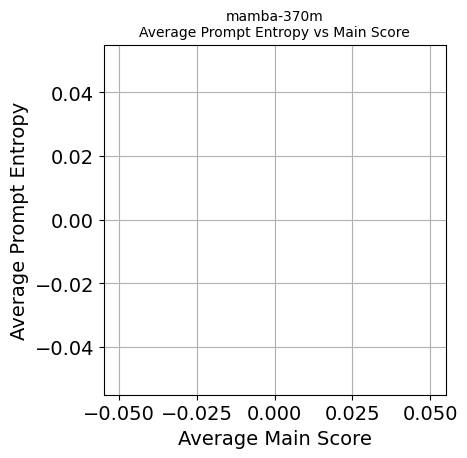

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec

METRICS_CHOICES = ['entropy_sentence', 
                   'entropy_dataset',
                   'infonce',
                   'lidar',
                   'dime',
                   # 'dime_normalized_a',
                   'dime_normalized_b']

TASKS = ['MTOPDomainClassification', 'EmotionClassification', 'SprintDuplicateQuestions', 'STS13', 'STS12', 'TwitterSemEval2015', 'BIOSSES', 'TwentyNewsgroupsClustering', 'MassiveIntentClassification', 'STSBenchmark', 'RedditClustering', 'MTOPIntentClassification', 'STS15', 'MedrxivClusteringS2S', 'SciDocsRR', 'StackOverflowDupQuestions', 'BiorxivClusteringS2S', 'StackExchangeClustering', 'ArxivClusteringS2S', 'ToxicConversationsClassification', 'SICK-R', 'TwitterURLCorpus', 'MindSmallReranking', 'MassiveScenarioClassification', 'Banking77Classification', 'AmazonCounterfactualClassification', 'STS16', 'AmazonReviewsClassification', 'AskUbuntuDupQuestions', 'STS14', 'TweetSentimentExtractionClassification', 'STS17']
    

## for collecting data to calculate correlations
cor_sententropy = dict()
cor_dataentropy = dict()
cor_dime = dict()
cor_lidar = dict()
cor_infonce = dict()
cor_dimentropy = dict()
cor_dimentropyb = dict()

for i in ['rho', 'tau', 'mic', 'dcor']:
    cor_sententropy[i] = -999
    cor_dime[i] = -999    
    cor_lidar[i] = -999
    cor_infonce[i] = -999
    cor_dimentropy[i] = -999   
    cor_dimentropyb[i] = -999

MODEL="mamba"
MODELSIZE="370m"

# MODEL="Pythia"
# MODELSIZE="410m"

model_specs = TextModelSpecifications(
    model_family=MODEL,
    model_size=MODELSIZE,
    # model_size='14m',
    revision='main'
)

## for collecting separate data to try combos
sententropy = dict()
dataentropy = dict()
dime_m = dict()
lidar_m = dict()
infonce_m = dict()
dimentropy = dict()
dimentropyb = dict()

for i in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
    if i.startswith('layer_'):
        sententropy[i] = dict()
        dataentropy[i] = dict()
        dime_m[i] = dict()
        lidar_m[i] = dict()
        infonce_m[i] = dict()
        dimentropy[i] = dict()
        dimentropyb[i] = dict()
        for j in TASKS:
            sententropy[i][j] = []
            dataentropy[i][j] = []
            dime_m[i][j] = []
            lidar_m[i][j] = []
            infonce_m[i][j] = []
            dimentropy[i][j] = []            
            dimentropyb[i][j] = []        

perfscore_repmet_lyr_tsk = dict()

# Calculate number of rows and columns
n_cols = 3
# n_rows = (len(METRICS_CHOICES) + n_cols - 1) // n_cols  # Ceiling division
n_rows = 2

fig = plt.figure(figsize=(15, 5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig)

for idx, METRIC_TO_PLOT in enumerate(METRICS_CHOICES):
    x_values = []  # Main scores
    y_values = []  # Entropy values
    
    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT] = dict()
    
    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue

        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        
        perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer] = dict()
        
        # Calculate average main score for this layer
        main_scores = []
        metric_values = []
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])

                perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name] = []
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                    sententropy[layer][task_name].append(task_results['entropy_sentence']['maxEntropy'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                    dataentropy[layer][task_name].append(task_results['entropy_dataset']['maxEntropy'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(np.log(10000) - task_results['infonce']['raw'])
                    infonce_m[layer][task_name].append(np.log(10000) - task_results['infonce']['raw'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                    lidar_m[layer][task_name].append(task_results['lidar']['raw'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                    dime_m[layer][task_name].append(task_results['dime']['raw'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD']/task_results['entropy_sentence']['logD'])
                    dimentropy[layer][task_name].append(task_results['dime']['logD']/task_results['entropy_sentence']['logD'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw']/task_results['entropy_sentence']['maxEntropy'])
                    dimentropyb[layer][task_name].append(task_results['dime']['raw']/task_results['entropy_sentence']['maxEntropy'])
                    perfscore_repmet_lyr_tsk[METRIC_TO_PLOT][layer][task_name].append(task_results['main_score'])

            except KeyError:
                if main_scores:
                    main_scores.pop()  # Remove corresponding main score
                continue

        if main_scores and METRIC_TO_PLOT:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(metric_values))
    
    # if idx == len(METRICS_CHOICES) - 1 and len(METRICS_CHOICES) % n_cols != 0:  # Last plot is a straggler
    #     ax = fig.add_subplot(gs[-1, n_cols // 2])  # Center it in the last row
    # else:
        # ax = fig.add_subplot(gs[idx // n_cols, idx % n_cols])

    ax = fig.add_subplot(gs[idx // n_cols, idx % n_cols])    

    # Plot data
    ax.scatter(x_values, y_values, alpha=0.5)
    ax.set_xlabel('Average Main Score')
    
    if METRIC_TO_PLOT == "entropy_sentence":
        ax.set_ylabel(f'Average Prompt Entropy')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage Prompt Entropy vs Main Score', fontsize=10)
    elif METRIC_TO_PLOT == "entropy_dataset":        
        ax.set_ylabel(f'Average Dataset Entropy')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage Dataset Entropy vs Main Score', fontsize=10)
    elif METRIC_TO_PLOT == "infonce":        
        ax.set_ylabel(f'Average InfoNCE')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage infoNCE vs Main Score', fontsize=10)
    elif METRIC_TO_PLOT == "lidar":        
        ax.set_ylabel(f'Average LiDAR')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage LiDAR vs Main Score', fontsize=10)
    elif METRIC_TO_PLOT == "dime":        
        ax.set_ylabel(f'Average DiME')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage DiME vs Main Score', fontsize=10)
    # elif METRIC_TO_PLOT == "dime_normalized_a":        
    #     ax.set_ylabel(f'Average Curvature')
    #     ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage Curvature vs Main Score', fontsize=10)
    elif METRIC_TO_PLOT == "dime_normalized_b":        
        ax.set_ylabel(f'Average Curvature')
        ax.set_title(f'{model_specs.model_family}-{model_specs.model_size}\nAverage Curvature vs Main Score', fontsize=10)

    ax.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(x_values, y_values)
    ax.text(0.05, 0.15, f'Correlation: {correlation:.3f}\nP-value: {p_value:.3f}', 
            transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    # Add negative diagonal line
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    mine = MINE(alpha=0.6, c=15)
    mine.compute_score(x_values, y_values)
    dcor_value = dcor.distance_correlation(np.array(x_values), np.array(y_values))

    if METRIC_TO_PLOT == "entropy_sentence":
        cor_sententropy['rho'] = correlation
        cor_sententropy['tau'] = kendalltau(x_values, y_values).statistic
        cor_sententropy['mic'] = mine.mic()
        cor_sententropy['dcor'] = dcor_value
    if METRIC_TO_PLOT == "entropy_dataset":
        cor_dataentropy['rho'] = correlation
        cor_dataentropy['tau'] = kendalltau(x_values, y_values).statistic
        cor_dataentropy['mic'] = mine.mic()
        cor_dataentropy['dcor'] = dcor_value        
    if METRIC_TO_PLOT == "dime":
        cor_dime['rho'] = correlation
        cor_dime['tau'] = kendalltau(x_values, y_values).statistic
        cor_dime['mic'] = mine.mic()
        cor_dime['dcor'] = dcor_value
    if METRIC_TO_PLOT == "lidar":
        cor_lidar['rho'] = correlation
        cor_lidar['tau'] = kendalltau(x_values, y_values).statistic
        cor_lidar['mic'] = mine.mic()
        cor_lidar['dcor'] = dcor_value
    if METRIC_TO_PLOT == "infonce": ## to account for recalculated infonce offset
        cor_infonce['rho'] = correlation
        cor_infonce['tau'] = kendalltau(x_values, y_values).statistic
        cor_infonce['mic'] = mine.mic()
        cor_infonce['dcor'] = dcor_value
    # if METRIC_TO_PLOT == 'dime_normalized_a':
    #     cor_dimentropy['rho'] = correlation
    #     cor_dimentropy['tau'] = kendalltau(x_values, y_values).statistic
    #     cor_dimentropy['mic'] = mine.mic()
    #     cor_dimentropy['dcor'] = dcor_value
    if METRIC_TO_PLOT == 'dime_normalized_b':
        cor_dimentropy['rho'] = correlation
        cor_dimentropy['tau'] = kendalltau(x_values, y_values).statistic
        cor_dimentropy['mic'] = mine.mic()
        cor_dimentropy['dcor'] = dcor_value
            

# Final layout adjustments
plt.tight_layout()
plt.savefig(f"{MODEL}{MODELSIZE}_repmetric_perf_lineplots.pdf")
plt.show()


In [34]:
len(main_scores)

0

In [9]:
# sententropy
# dataentropy
# dime_m
# lidar_m
# infonce_m
# dimentropy
# dimentropyb

from collections import defaultdict

repmet_data = sententropy
#repmet_data =  dataentropy
#repmet_data =  dime_m
#repmet_data =  lidar_m
#repmet_data =  infonce_m
#repmet_data =  dimentropy
#repmet_data =  dimentropyb

missing = []

for k,v in repmet_data.items():
    for ki, vi in v.items():
        if not vi:
            missing.append((k,ki))

missing_ct = defaultdict(set)

for layer, element in missing:
    missing_ct[layer].add(element)

unique_element_counts = {layer: len(elements) for layer, elements in missing_ct.items()}
unique_element_counts

{'layer_0': 8,
 'layer_1': 8,
 'layer_2': 8,
 'layer_3': 8,
 'layer_4': 8,
 'layer_5': 8,
 'layer_6': 8,
 'layer_7': 8,
 'layer_8': 8,
 'layer_9': 8,
 'layer_10': 8,
 'layer_11': 8,
 'layer_12': 8,
 'layer_13': 8,
 'layer_14': 8,
 'layer_15': 8,
 'layer_16': 8,
 'layer_17': 8,
 'layer_18': 8,
 'layer_19': 8,
 'layer_20': 8,
 'layer_21': 8,
 'layer_22': 8,
 'layer_23': 8,
 'layer_24_last': 32,
 'layer_24': 8}

In [4]:
assert sententropy.keys() == dataentropy.keys() == dime_m.keys() == lidar_m.keys() == infonce_m.keys() == dimentropy.keys() == dimentropyb.keys()

# repmets_lyr_avgmets = dict()
# repmets_met_avglyrs = dict()

# for i in sententropy.keys():
#     if i != "layer_24_last":
#         repmets_lyr_avgmets[i] = []

        
# for j in [sententropy, dataentropy, dime_m, lidar_m, infonce_m, dimentropy, dimentropyb]:
#     for k,v in j.items():
#         if k != "layer_24_last":
#              repmets_lyr_avgmets[k].append(v)

# artavg_repmets = dict()
# geoavg_repmets = dict()
# znorm_repmets = dict()

# for i in sententropy.keys():
#     if i != "layer_24_last":
#         avg_repmets[i] = np.mean([sententropy[i], dataentropy[i], dime_m[i],  )
        

In [5]:
# sententropy
# dataentropy
# dime_m
# lidar_m
# infonce_m
# dimentropy
# dimentropyb

sententropy_avgtask = dict()
for layer, tasks in sententropy.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        sententropy_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                sententropy_avgtask[layer].append(task_rep_mets[0])

dataentropy_avgtask = dict()
for layer, tasks in dataentropy.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dataentropy_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dataentropy_avgtask[layer].append(task_rep_mets[0])

dime_m_avgtask = dict()
for layer, tasks in dime_m.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dime_m_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dime_m_avgtask[layer].append(task_rep_mets[0])

lidar_m_avgtask = dict()
for layer, tasks in lidar_m.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        lidar_m_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                lidar_m_avgtask[layer].append(task_rep_mets[0])

infonce_m_avgtask = dict()
for layer, tasks in infonce_m.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        infonce_m_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                infonce_m_avgtask[layer].append(task_rep_mets[0])

# dimentropy_avgtask = dict()
# for layer, tasks in dimentropy.items():
#     if layer.startswith("layer_") and not layer.endswith("_last"):
#         dimentropy_avgtask[layer] = []
#         for task, task_rep_mets in tasks.items():
#             if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
#                 dimentropy_avgtask[layer].append(task_rep_mets[0])

dimentropyb_avgtask = dict()
for layer, tasks in dimentropyb.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dimentropyb_avgtask[layer] = []
        for task, task_rep_mets in tasks.items():
            if task_rep_mets and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dimentropyb_avgtask[layer].append(task_rep_mets[0])

In [6]:
sententropy_lyr_perf = perfscore_repmet_lyr_tsk["entropy_sentence"]
dataentropy_lyr_perf = perfscore_repmet_lyr_tsk["entropy_dataset"]
infonce_lyr_perf = perfscore_repmet_lyr_tsk["infonce"]
lidar_lyr_perf = perfscore_repmet_lyr_tsk["lidar"]
dime_lyr_perf = perfscore_repmet_lyr_tsk["dime"]
# dimenorma_lyr_perf = perfscore_repmet_lyr_tsk["dime_normalized_a"]
dimenormb_lyr_perf = perfscore_repmet_lyr_tsk["dime_normalized_b"]

sententropy_lyrperf = dict()
for layer, tasks in sententropy_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        sententropy_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                sententropy_lyrperf[layer].append(task_scores[0])

dataentropy_lyrperf = dict()
for layer, tasks in dataentropy_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dataentropy_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dataentropy_lyrperf[layer].append(task_scores[0])

infonce_lyrperf = dict()
for layer, tasks in infonce_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        infonce_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                infonce_lyrperf[layer].append(task_scores[0])

lidar_lyrperf = dict()
for layer, tasks in lidar_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        lidar_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                lidar_lyrperf[layer].append(task_scores[0])

dime_lyrperf = dict()
for layer, tasks in dime_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dime_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dime_lyrperf[layer].append(task_scores[0])

# dimenorma_lyrperf = dict()
# for layer, tasks in dimenorma_lyr_perf.items():
#     if layer.startswith("layer_") and not layer.endswith("_last"):
#         dimenorma_lyrperf[layer] = []
#         for task, task_scores in tasks.items():
#             if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
#                 dimenorma_lyrperf[layer].append(task_scores[0])

dimenormb_lyrperf = dict()
for layer, tasks in dimenormb_lyr_perf.items():
    if layer.startswith("layer_") and not layer.endswith("_last"):
        dimenormb_lyrperf[layer] = []
        for task, task_scores in tasks.items():
            if task_scores and task not in ('MTOPDomainClassification', 'SprintDuplicateQuestions', 'TwitterSemEval2015', 'MassiveIntentClassification', 'MTOPIntentClassification', 'TwitterURLCorpus', 'MassiveScenarioClassification', 'TweetSentimentExtractionClassification'):
                dimenormb_lyrperf[layer].append(task_scores[0])

In [7]:
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel
from scipy.stats import pearsonr, rankdata, norm
import dcor
from minepy import MINE
from scipy.stats import kendalltau


# tau, p_value = stats.kendalltau(x1, x2)

sent_deps = dict()
data_deps = dict()
infonce_deps = dict()
dime_deps = dict()
lidar_deps = dict()
dimenorma_deps = dict()
dimenormb_deps = dict()

for i in range(25):
    l = f"layer_{i}"
    sent_deps[l] = dict()
    data_deps[l] = dict()
    infonce_deps[l] = dict()
    dime_deps[l] = dict()    
    lidar_deps[l] = dict()
    dimenorma_deps[l] = dict()    
    dimenormb_deps[l] = dict()    
    for j in ["rho", "tau", "MIC", "dcor"]:
        if j == "rho":
            sent_deps[l][j] = pearsonr(sententropy_avgtask[l], sententropy_lyrperf[l]).statistic
            data_deps[l][j] = pearsonr(dataentropy_avgtask[l], dataentropy_lyrperf[l]).statistic
            infonce_deps[l][j] = pearsonr(infonce_m_avgtask[l], infonce_lyrperf[l]).statistic
            dime_deps[l][j] = pearsonr(dime_m_avgtask[l], dime_lyrperf[l]).statistic
            lidar_deps[l][j] = pearsonr(lidar_m_avgtask[l], lidar_lyrperf[l]).statistic
            # dimenorma_deps[l][j] = pearsonr(dimentropy_avgtask[l], dimenorma_lyrperf[l]).statistic
            dimenormb_deps[l][j] = pearsonr(dimentropyb_avgtask[l], dimenormb_lyrperf[l]).statistic 
        elif j == "tau":
            sent_deps[l][j] = kendalltau(sententropy_avgtask[l], sententropy_lyrperf[l]).statistic
            data_deps[l][j] = kendalltau(dataentropy_avgtask[l], dataentropy_lyrperf[l]).statistic
            infonce_deps[l][j] = kendalltau(infonce_m_avgtask[l], infonce_lyrperf[l]).statistic
            dime_deps[l][j] = kendalltau(dime_m_avgtask[l], dime_lyrperf[l]).statistic
            lidar_deps[l][j] = kendalltau(lidar_m_avgtask[l], lidar_lyrperf[l]).statistic
            # dimenorma_deps[l][j] = kendalltau(dimentropy_avgtask[l], dimenorma_lyrperf[l]).statistic
            dimenormb_deps[l][j] = kendalltau(dimentropyb_avgtask[l], dimenormb_lyrperf[l]).statistic
        elif j == "MIC":        
            mine = MINE(alpha=0.6, c=15)
            mine.compute_score(sententropy_avgtask[l], sententropy_lyrperf[l])
            sent_deps[l][j] = mine.mic()

            mine = MINE(alpha=0.6, c=15)            
            mine.compute_score(dataentropy_avgtask[l], dataentropy_lyrperf[l])
            data_deps[l][j] = mine.mic()

            mine = MINE(alpha=0.6, c=15)            
            mine.compute_score(infonce_m_avgtask[l], infonce_lyrperf[l])
            infonce_deps[l][j] = mine.mic()

            mine = MINE(alpha=0.6, c=15)            
            mine.compute_score(dime_m_avgtask[l], dime_lyrperf[l])
            dime_deps[l][j] = mine.mic()

            mine = MINE(alpha=0.6, c=15)            
            mine.compute_score(lidar_m_avgtask[l], lidar_lyrperf[l])
            lidar_deps[l][j] = mine.mic()

            # mine = MINE(alpha=0.6, c=15)            
            # mine.compute_score(dimentropy_avgtask[l], dimenorma_lyrperf[l])
            # dimenorma_deps[l][j] = mine.mic()

            mine = MINE(alpha=0.6, c=15)            
            mine.compute_score(dimentropyb_avgtask[l], dimenormb_lyrperf[l])
            dimenormb_deps[l][j] = mine.mic()
            
        elif j == "dcor":
            sent_deps[l][j] = dcor.distance_correlation(np.array(sententropy_avgtask[l]), np.array(sententropy_lyrperf[l]))
            data_deps[l][j] = dcor.distance_correlation(np.array(dataentropy_avgtask[l]), np.array(dataentropy_lyrperf[l]))
            infonce_deps[l][j] = dcor.distance_correlation(np.array(infonce_m_avgtask[l]), np.array(infonce_lyrperf[l]))
            dime_deps[l][j] = dcor.distance_correlation(np.array(dime_m_avgtask[l]), np.array(dime_lyrperf[l]))
            lidar_deps[l][j] = dcor.distance_correlation(np.array(lidar_m_avgtask[l]), np.array(lidar_lyrperf[l]))
            # dimenorma_deps[l][j] = dcor.distance_correlation(np.array(dimentropy_avgtask[l]), np.array(dimenorma_lyrperf[l]))
            dimenormb_deps[l][j] = dcor.distance_correlation(np.array(dimentropyb_avgtask[l]), np.array(dimenormb_lyrperf[l]))


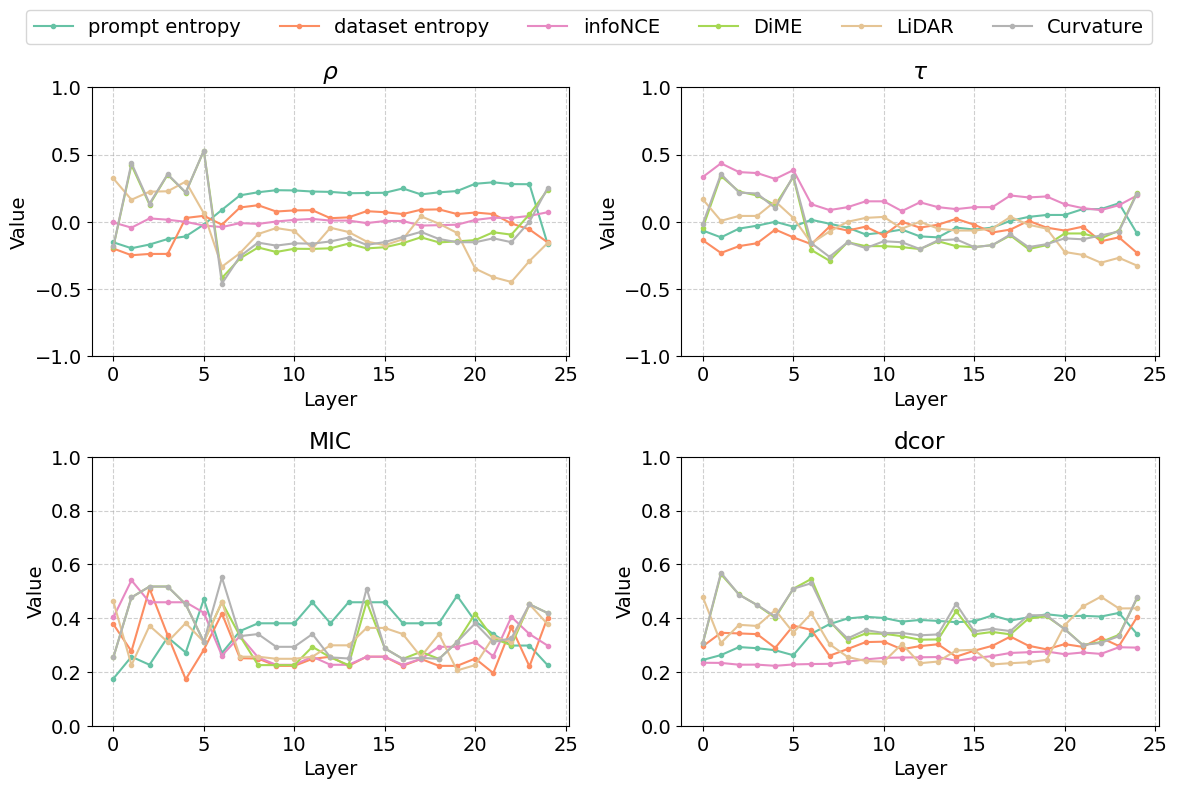

In [8]:
# repdicts = [sent_deps, data_deps, infonce_deps, dime_deps, lidar_deps, dimenorma_deps, dimenormb_deps]
repdicts = [sent_deps, data_deps, infonce_deps, dime_deps, lidar_deps, dimenormb_deps]
# repdicts_n = ["sent. entropy", "data entropy", "infoNCE", "DIME", "LIDAR", "DIME/entropyA", "DIME/entropyB"]
repdicts_n = ["prompt entropy", "dataset entropy", "infoNCE", "DiME", "LiDAR", "Curvature"]

metrics = ['rho', 'tau', 'MIC', 'dcor']
layer_labels = [int(key.split('_')[-1]) for key in repdicts[0].keys()]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.flatten()

soft_colors = plt.cm.Set2(np.linspace(0, 1, len(repdicts)))  # Use Set2 for softer but distinctive shades

for i, metric in enumerate(metrics):
    ax = axes[i]
    for d_idx, (name, d) in enumerate(zip(repdicts_n, repdicts)):
        values = [d[f'layer_{layer}'][metric] for layer in layer_labels]
        ax.plot(layer_labels, values, marker='.', label=name, color=soft_colors[d_idx])

    if metric == "rho":
        title = r"$\rho$"
        ax.set_title(title)
    elif metric == "tau":
        title = r"$\tau$"
        ax.set_title(title)
    else:
        title = metric
        ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i < 2:  # Top row (rho, tau)
        ax.set_ylim(-1, 1)
    else:  # Bottom row (MIC, dcor)
        ax.set_ylim(0, 1)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(repdicts_n), bbox_to_anchor=(0.5, 1.0))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pythia410m_infomet_taskperf_overdepth.pdf")
plt.show()

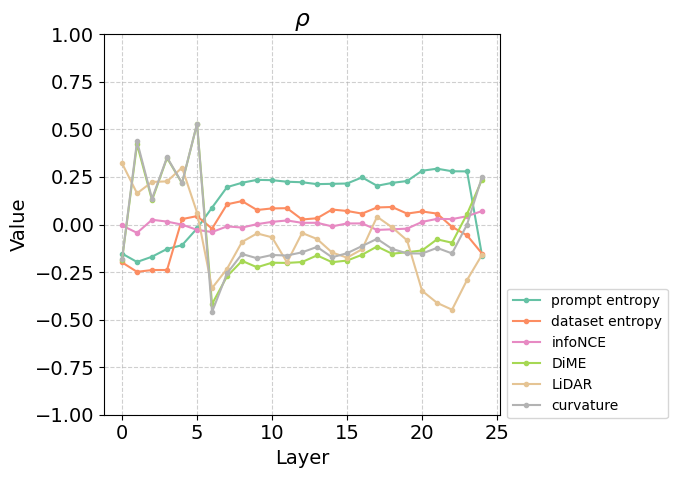

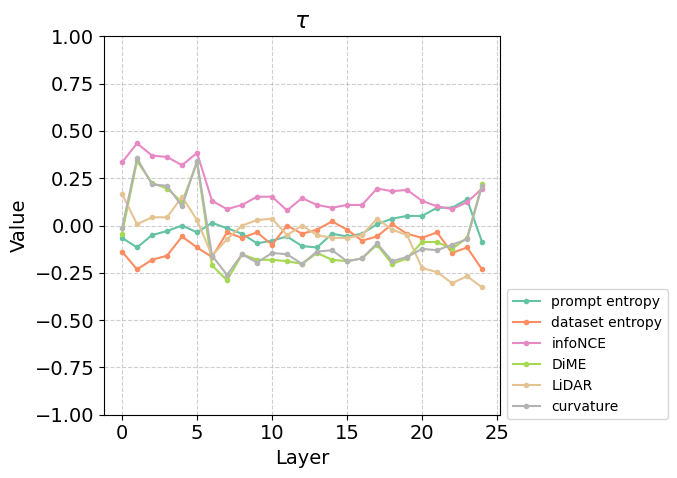

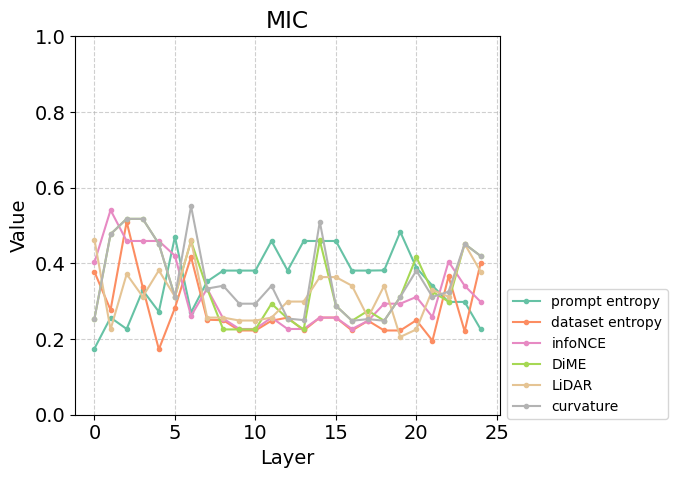

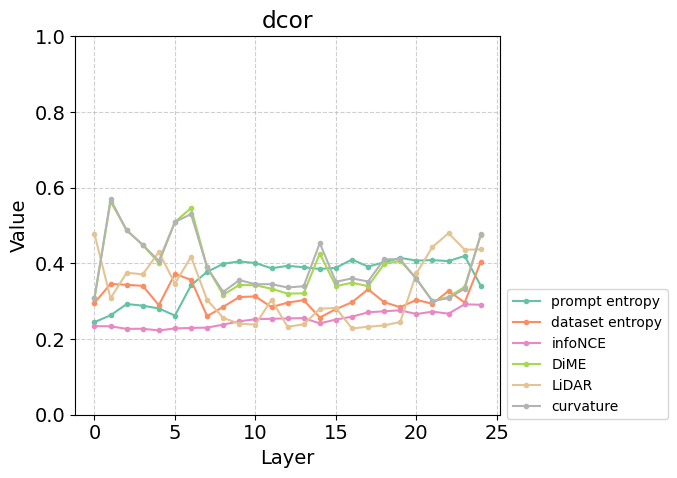

In [31]:
# repdicts = [sent_deps, data_deps, infonce_deps, dime_deps, lidar_deps, dimenorma_deps, dimenormb_deps]
repdicts = [sent_deps, data_deps, infonce_deps, dime_deps, lidar_deps, dimenormb_deps]
# repdicts_n = ["sent. entropy", "data entropy", "infoNCE", "DIME", "LIDAR", "DIME/entropyA", "DIME/entropyB"]
repdicts_n = ["prompt entropy", "dataset entropy", "infoNCE", "DiME", "LiDAR", "curvature"]

metrics = ['rho', 'tau', 'MIC', 'dcor']
layer_labels = [int(key.split('_')[-1]) for key in repdicts[0].keys()]

soft_colors = plt.cm.Set2(np.linspace(0, 1, len(repdicts)))  # Use Set2 for softer but distinctive shades

for i, metric in enumerate(metrics):
    plt.figure(figsize=(7, 5))
    for d_idx, (name, d) in enumerate(zip(repdicts_n, repdicts)):
        values = [d[f'layer_{layer}'][metric] for layer in layer_labels]
        plt.plot(layer_labels, values, marker='.', label=name, color=soft_colors[d_idx])
    
    if metric == "rho":
        title = r"$\rho$"
    elif metric == "tau":
        title = r"$\tau$"
    else:
        title = metric
    
    plt.title(title)
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if i < 2:  # rho, tau
        plt.ylim(-1, 1)
    else:  # MIC, dcor
        plt.ylim(0, 1)
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, .35), fontsize=10)  # Smaller legend font size
    plt.tight_layout()
    filename = f"{MODEL}{MODELSIZE}_{metric}_over_layers.pdf"
    plt.savefig(filename)
    plt.show()

In [18]:
# sententropy
# dataentropy
# dime_m
# lidar_m
# infonce_m
# dimentropy
# dimentropyb


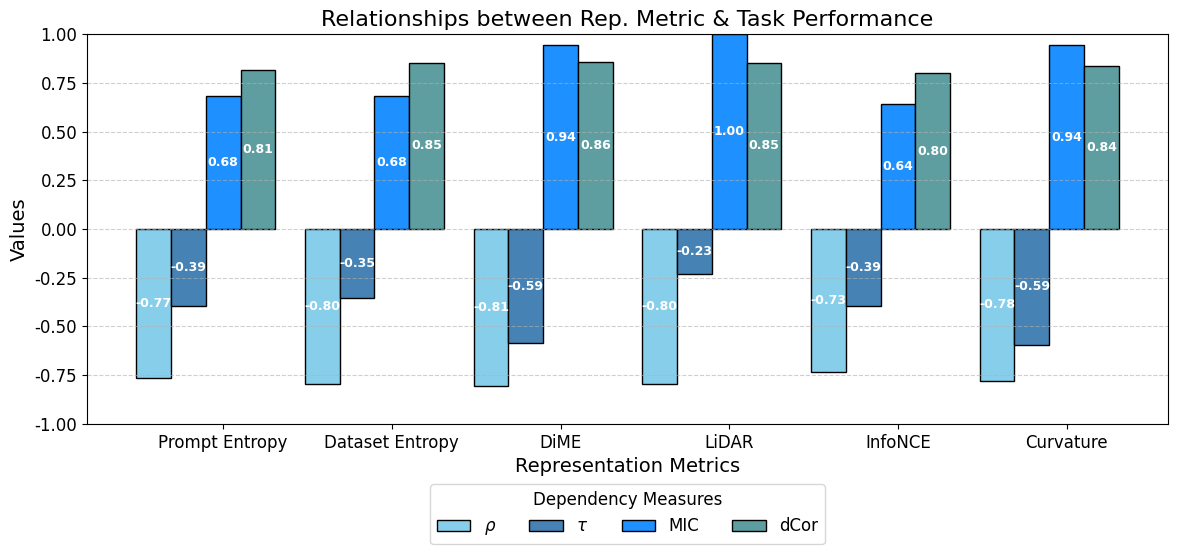

In [30]:
categories = ["Prompt Entropy", "Dataset Entropy", "DiME", "LiDAR", "InfoNCE", "Curvature"]
subcategories = [r"$\rho$", r"$\tau$", "MIC", "dCor"]

colors = ['#87CEEB', '#4682B4', '#1E90FF', '#5F9EA0']

# Adjust bar width to make bars wider and properly align x-axis labels
bar_width = 0.33 
group_spacing = 0.6 
x = np.arange(len(categories)) * (1 + group_spacing)  # Adjust x positions

vals = np.array([
    [i for i in cor_sententropy.values()],
    [i for i in cor_dataentropy.values()],    
    [i for i in cor_dime.values()],
    [i for i in cor_lidar.values()],
    [i for i in cor_infonce.values()],
    [i for i in cor_dimentropy.values()]
])

plt.figure(figsize=(12, 6))

for i, (subcat, color) in enumerate(zip(subcategories, colors)):
    bars = plt.bar(x + i * bar_width - (len(subcategories) * bar_width / 2),  # Center bars properly
                   vals[:, i], 
                   bar_width, 
                   label=subcat, 
                   color=color, 
                   edgecolor='black')

    # Add labels inside bars
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center of the bar
            bar.get_height() / 2,  
            f'{bar.get_height():.2f}', 
            ha='center', va='center', color='white', fontsize=9, fontweight='bold'
        )

# Update plot labels and title
plt.title('Relationships between Rep. Metric & Task Performance', fontsize=16)
plt.xlabel('Representation Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)

# Adjust xticks to center correctly
plt.xticks(x, categories, fontsize=12)

plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.ylim(-1, 1)

# Update legend position
plt.legend(
    title='Dependency Measures',
    fontsize=12,
    title_fontsize=12,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.33),
    ncol=4
)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pythia410m_simple_barplot_perfmetric_corr.pdf")
plt.show()



In [10]:
cor_sententropy

{'rho': -0.7653867297083493,
 'tau': -0.39333333333333326,
 'mic': 0.6815101887362597,
 'dcor': 0.814104312280137}

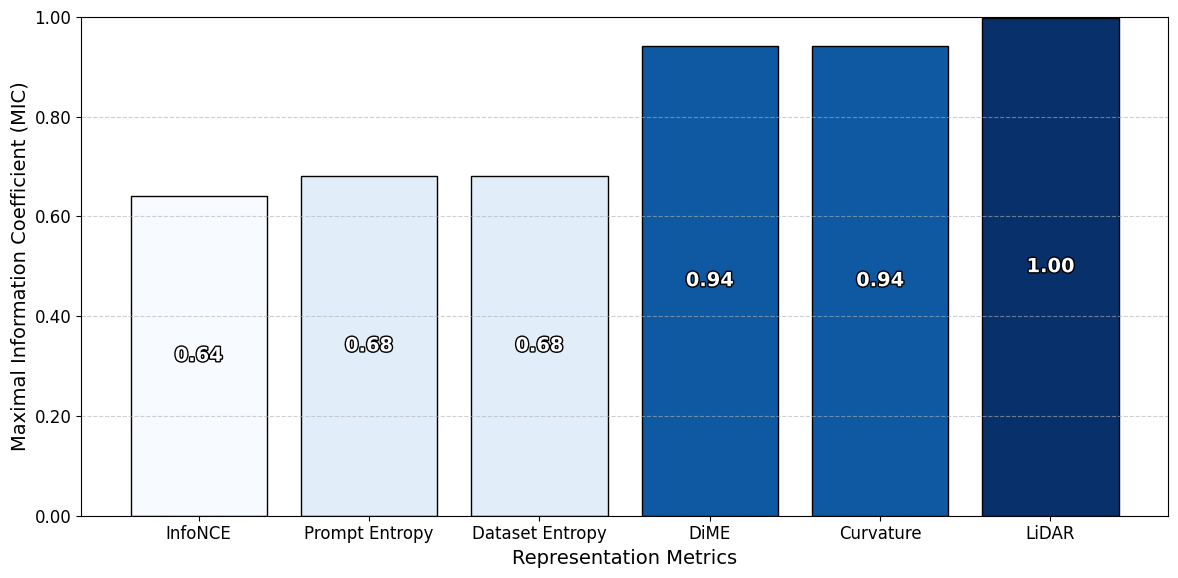

In [13]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patheffects as path_effects

categories = ["Prompt Entropy", "Dataset Entropy", "DiME", "LiDAR", "InfoNCE", "Curvature"]
# corr_met = "rho"
corr_key = "mic"
rho_values = np.array([
    cor_sententropy[corr_key],
    cor_dataentropy[corr_key],    
    cor_dime[corr_key],
    cor_lidar[corr_key],
    cor_infonce[corr_key],
    cor_dimentropy[corr_key]
])

sorted_indices = np.argsort(rho_values)
categories = [categories[i] for i in sorted_indices]
rho_values = rho_values[sorted_indices]
x = np.arange(len(categories))  # X positions for bars

# Create a color gradient with light to dark shades
norm = mcolors.Normalize(vmin=min(rho_values), vmax=max(rho_values))
colors = cm.Blues(norm(rho_values))  # Adjusting for light to dark gradient

plt.figure(figsize=(12, 6))

# Plot only rho values as a single bar per category
bars = plt.bar(x, rho_values, color=colors, edgecolor='black')

# Add labels inside bars with larger font size and outline
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center of the bar
        bar.get_height() / 2,  
        f'{bar.get_height():.2f}', 
        ha='center', va='center', color='white', fontsize=14, fontweight='bold',
        path_effects=[path_effects.withStroke(linewidth=2, foreground='black')]
    )

plt.xlabel('Representation Metrics', fontsize=14)
plt.ylabel('Maximal Information Coefficient (MIC)', fontsize=14)

# Adjust xticks to center correctly
plt.xticks(x, categories, fontsize=12)

plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{MODEL}{MODELSIZE}_simple_barplot_perfmetric_{corr_key}.pdf")
plt.show()


# Single Layer, Metric vs Main Score for each task

### old

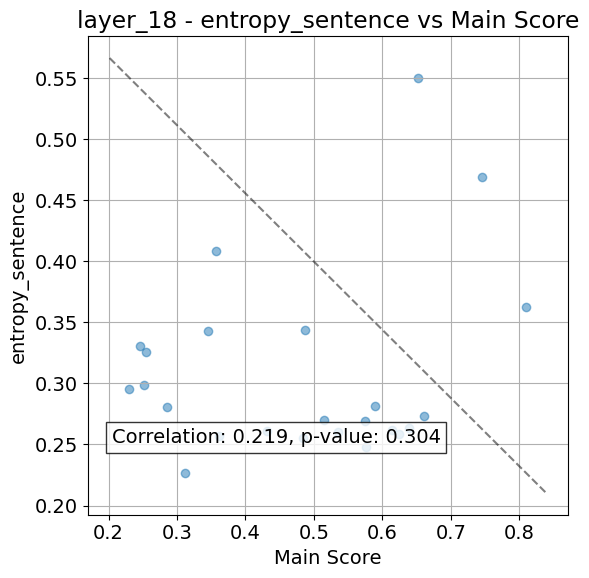

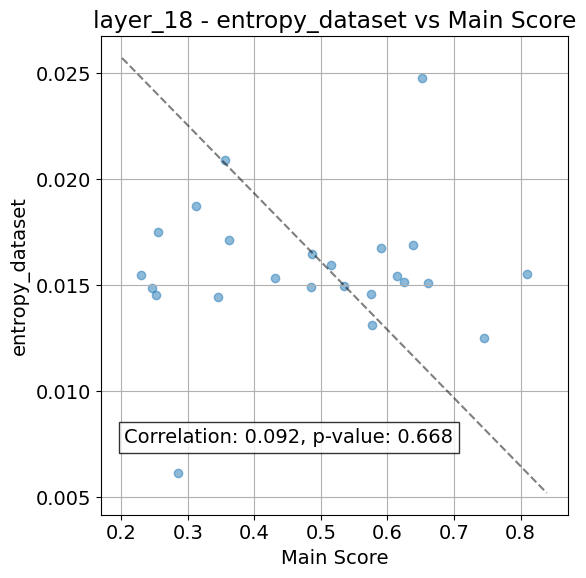

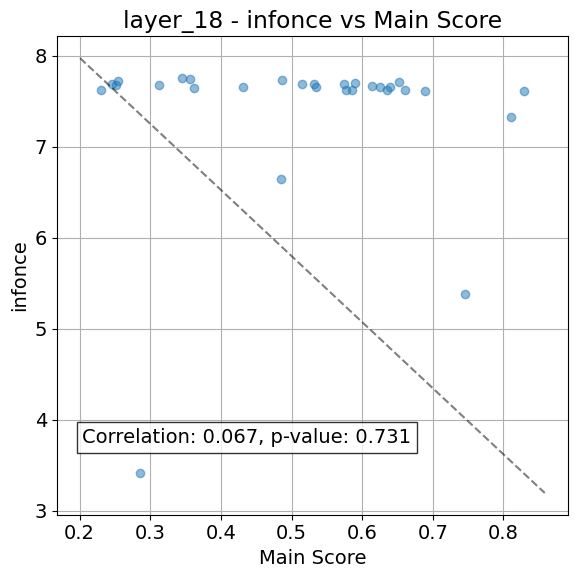

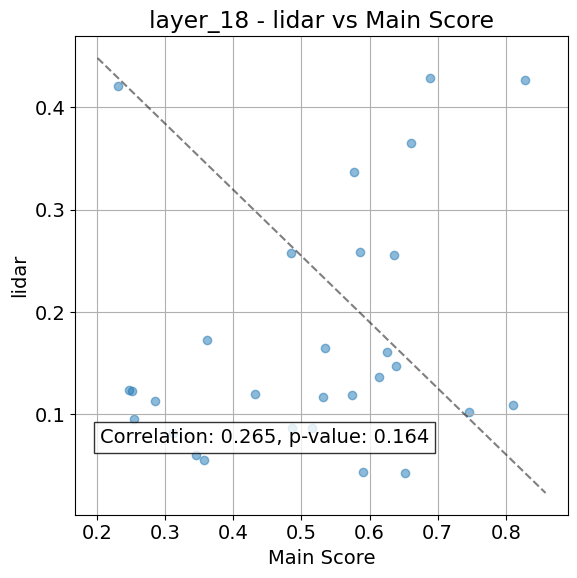

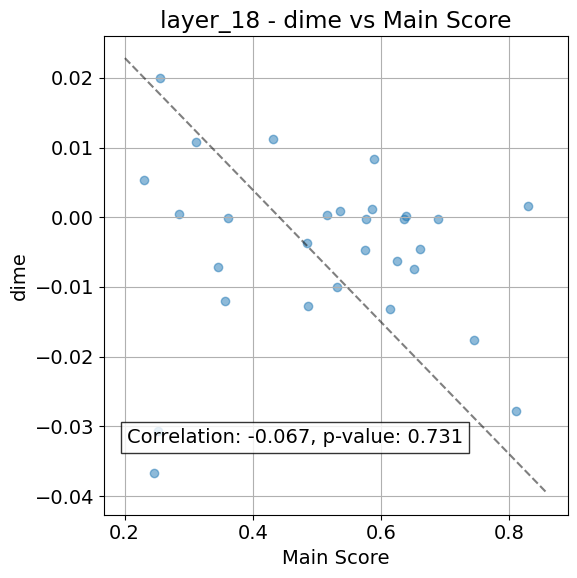

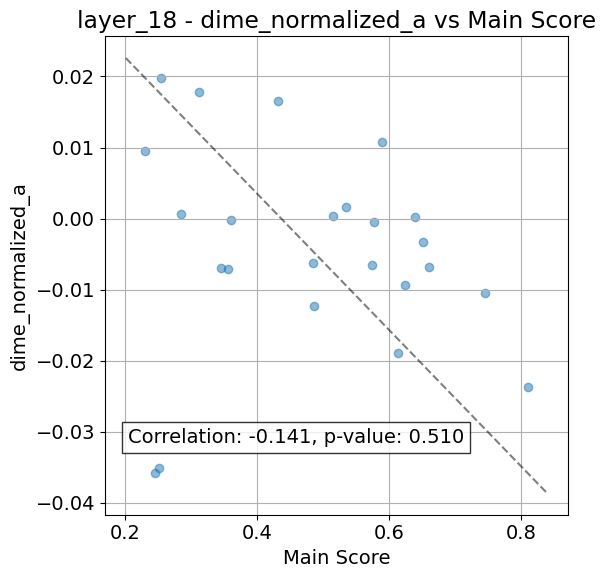

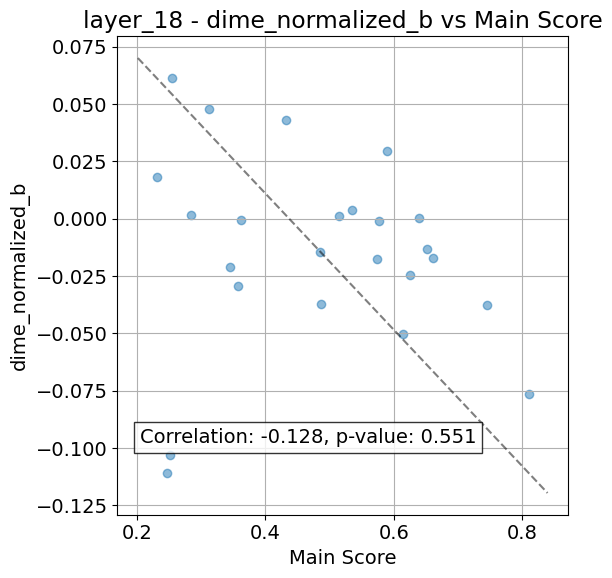

In [78]:
METRICS_CHOICES = ['entropy_sentence', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']
LAYER_TO_PLOT = 'layer_18'

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    main_scores = []
    metric_values = []

    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
        if layer != LAYER_TO_PLOT:
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_sentence']['maxEntropy'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue

    # Create square scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(main_scores, metric_values, alpha=0.5)
    plt.xlabel('Main Score')
    plt.ylabel(f'{METRIC_TO_PLOT}')
    plt.title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT} vs Main Score')
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(main_scores, metric_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

## new

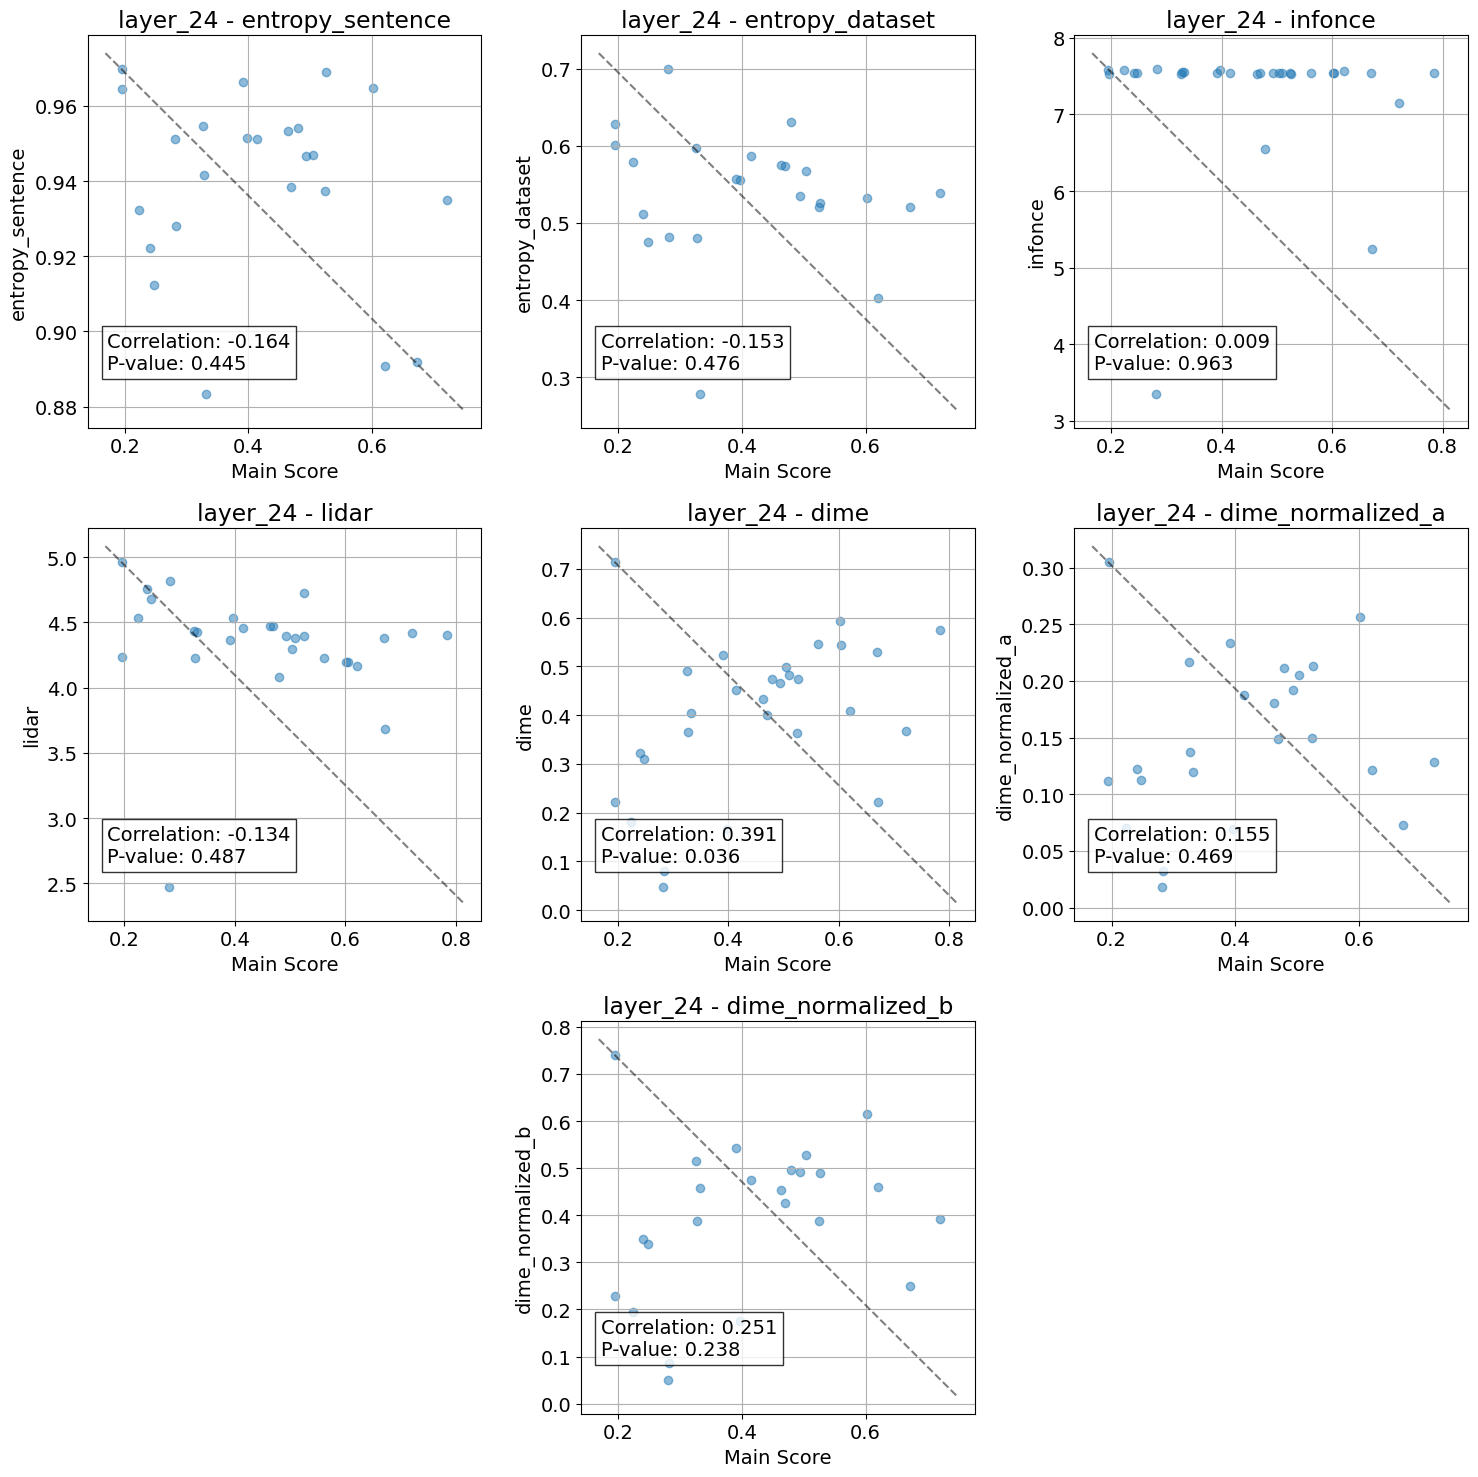

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec

METRICS_CHOICES = ['entropy_sentence', 
                   'entropy_dataset',
                   'infonce',
                   'lidar',
                   'dime',
                   'dime_normalized_a',
                   'dime_normalized_b']
LAYER_TO_PLOT = 'layer_24'

cor_sententropy_lyr = dict()
cor_dataentropy_lyr = dict()
cor_dime_lyr = dict()
cor_lidar_lyr = dict()
cor_infonce_lyr = dict()
cor_dimentropy_lyr = dict()
cor_dimentropyb_lyr = dict()

for i in ['rho', 'tau', 'mic', 'dcor']:
    cor_sententropy_lyr[i] = -999
    cor_dime_lyr[i] = -999    
    cor_lidar_lyr[i] = -999
    cor_infonce_lyr[i] = -999
    cor_dimentropy_lyr[i] = -999   
    cor_dimentropyb_lyr[i] = -999

model_specs = TextModelSpecifications(
    model_family=MODEL,
    model_size=MODELSIZE,
    revision='main'
)

# Calculate number of rows and columns
n_cols = 3
n_rows = (len(METRICS_CHOICES) + n_cols - 1) // n_cols  # Ceiling division

fig = plt.figure(figsize=(15, 5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig)

axes = []  # Keep track of all axes for managing unused ones later

for idx, METRIC_TO_PLOT in enumerate(METRICS_CHOICES):
    main_scores = []
    metric_values = []

    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
        if layer != LAYER_TO_PLOT:
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_sentence':
                    metric_values.append(task_results['entropy_sentence']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_sentence']['maxEntropy'])

            except KeyError:
                if main_scores:
                    main_scores.pop()  # Remove corresponding main score
                continue

    # Determine subplot location
    if idx == len(METRICS_CHOICES) - 1 and len(METRICS_CHOICES) % n_cols != 0:  # Last plot is a straggler
        ax = fig.add_subplot(gs[-1, n_cols // 2])  # Center it in the last row
    else:
        ax = fig.add_subplot(gs[idx // n_cols, idx % n_cols])

    axes.append(ax)  # Add the axis to the list

    # Plot data
    ax.scatter(main_scores, metric_values, alpha=0.5)
    ax.set_xlabel('Main Score')
    ax.set_ylabel(f'{METRIC_TO_PLOT}')
    # ax.set_title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT} vs Main Score')
    ax.set_title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT}')
    ax.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(main_scores, metric_values)
    ax.text(0.05, 0.15, f'Correlation: {correlation:.3f}\nP-value: {p_value:.3f}', 
            transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8))

    # Add negative diagonal line
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)


    mine = MINE(alpha=0.6, c=7)
    mine.compute_score(x_values, y_values)
    dcor_value = dcor.distance_correlation(np.array(x_values), np.array(y_values))

    if METRIC_TO_PLOT == "entropy_sentence":
        cor_sententropy_lyr['rho'] = correlation
        cor_sententropy_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_sententropy_lyr['mic'] = mine.mic()
        cor_sententropy_lyr['dcor'] = dcor_value
    if METRIC_TO_PLOT == "entropy_dataset":
        cor_dataentropy_lyr['rho'] = correlation
        cor_dataentropy_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_dataentropy_lyr['mic'] = mine.mic()
        cor_dataentropy_lyr['dcor'] = dcor_value        
    if METRIC_TO_PLOT == "dime":
        cor_dime_lyr['rho'] = correlation
        cor_dime_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_dime_lyr['mic'] = mine.mic()
        cor_dime_lyr['dcor'] = dcor_value
    if METRIC_TO_PLOT == "lidar":
        cor_lidar_lyr['rho'] = correlation
        cor_lidar_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_lidar_lyr['mic'] = mine.mic()
        cor_lidar_lyr['dcor'] = dcor_value
    if METRIC_TO_PLOT == "infonce":
        cor_infonce_lyr['rho'] = correlation
        cor_infonce_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_infonce_lyr['mic'] = mine.mic()
        cor_infonce_lyr['dcor'] = dcor_value
    if METRIC_TO_PLOT == 'dime_normalized_a':
        cor_dimentropy_lyr['rho'] = correlation
        cor_dimentropy_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_dimentropy_lyr['mic'] = mine.mic()
        cor_dimentropy_lyr['dcor'] = dcor_value
    if METRIC_TO_PLOT == 'dime_normalized_b':
        cor_dimentropyb_lyr['rho'] = correlation
        cor_dimentropyb_lyr['tau'] = kendalltau(x_values, y_values).statistic
        cor_dimentropyb_lyr['mic'] = mine.mic()
        cor_dimentropyb_lyr['dcor'] = dcor_value
    

# Turn off unused axes
for ax in axes[len(METRICS_CHOICES):]:
    ax.axis('off')


# Final layout adjustments
plt.tight_layout()
plt.savefig(f"{LAYER_TO_PLOT}_{MODEL}{MODELSIZE}_repmetric_perf_lineplots.pdf")
plt.show()


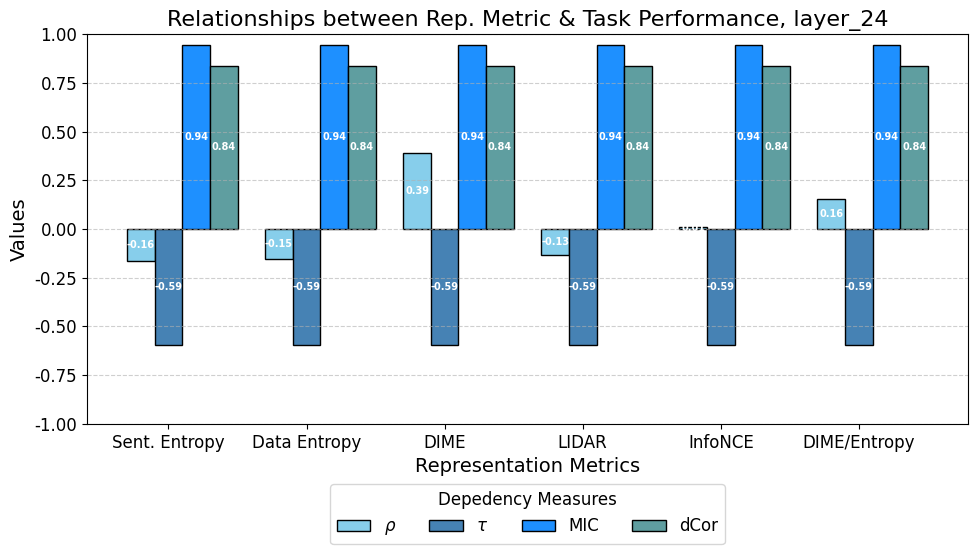

In [66]:
categories = ["Sent. Entropy", "Data Entropy", "DIME", "LIDAR", "InfoNCE", "DIME/Entropy"]
subcategories = [r"$\rho$", r"$\tau$", "MIC", "dCor"]

colors = ['#87CEEB', '#4682B4', '#1E90FF', '#5F9EA0']

bar_width = 0.2
x = np.arange(len(categories))

vals = np.array([
    [i for i in cor_sententropy_lyr.values()],
    [i for i in cor_dataentropy_lyr.values()],    
    [i for i in cor_dime_lyr.values()],
    [i for i in cor_lidar_lyr.values()],
    [i for i in cor_infonce_lyr.values()],
    [i for i in cor_dimentropy_lyr.values()]
])

plt.figure(figsize=(10, 6))

for i, (subcat, color) in enumerate(zip(subcategories, colors)):
    bars = plt.bar(x + i * bar_width, vals[:, i], bar_width, label=subcat, color=color, edgecolor='black')

    
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # Center of the bar
            bar.get_height() / 2,  
            f'{bar.get_height():.2f}', 
            ha='center', va='center', color='white', fontsize=7, fontweight='bold'
        )


plt.title(f'Relationships between Rep. Metric & Task Performance, {LAYER_TO_PLOT}', fontsize=16)
plt.xlabel('Representation Metrics', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.xticks(x + (len(subcategories) - 1) * bar_width / 3, categories, fontsize=12)  
# plt.xticks(x + (1.5 * bar_width), categories, fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.ylim(-1, 1)  
plt.legend(
    title='Depedency Measures',
    fontsize=12,
    title_fontsize=12,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.33),
    ncol=4
)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{LAYER_TO_PLOT}_{MODEL}{MODELSIZE}_simple_barplot_perfmetric_corr.pdf")
plt.show()

In [37]:
vals

array([[ 0.22, -0.59,  0.94,  0.84],
       [ 0.09, -0.59,  0.94,  0.84],
       [-0.07, -0.59,  0.94,  0.84],
       [ 0.27, -0.59,  0.94,  0.84],
       [ 0.07, -0.59,  0.94,  0.84],
       [-0.14, -0.59,  0.94,  0.84]])

In [40]:
vals

array([[ 0.21, -0.59,  0.94,  0.84],
       [ 0.03, -0.59,  0.94,  0.84],
       [-0.06, -0.59,  0.94,  0.84],
       [ 0.15, -0.59,  0.94,  0.84],
       [ 0.04, -0.59,  0.94,  0.84],
       [-0.1 , -0.59,  0.94,  0.84]])